# Credit Scoring — Exploratory Data Analysis

**Goal**: Understand the Home Credit Default Risk dataset, identify key predictive variables, and prepare the feature engineering pipeline to predict the probability of loan default (`TARGET = 1`).

**Dataset**: Home Credit Default Risk — [Kaggle Competition](https://www.kaggle.com/c/home-credit-default-risk)

**Metric**: AUC-ROC (target: ≥ 55%, ideally ≥ 62%)

---

## Table of Contents
1. [Imports & Setup](#1)
2. [Load Data](#2)
3. [Target Variable Distribution](#3)
4. [Missing Values](#4)
5. [Variable Types](#5)
6. [Numerical Features Analysis](#6)
7. [Categorical Features Analysis](#7)
8. [External Score Features (EXT_SOURCE)](#8)
9. [Correlation with TARGET](#9)
10. [Anomaly Detection](#10)
11. [Overview of Supplementary Tables](#11)
12. [Conclusions & Feature Engineering Plan](#12)

<a id='1'></a>
## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline

DATA_PATH = '../../data/'
print('Setup complete.')

Setup complete.


<a id='2'></a>
## 2. Load Data

We start with the two main tables: `application_train.csv` (labelled) and `application_test.csv` (unlabelled — Kaggle submission).

In [2]:
train = pd.read_csv(DATA_PATH + 'application_train.csv')
test  = pd.read_csv(DATA_PATH + 'application_test.csv')

print(f'Train : {train.shape[0]:,} rows  × {train.shape[1]} columns')
print(f'Test  : {test.shape[0]:,} rows  × {test.shape[1]} columns')
print(f'\nTrain columns not in Test : {set(train.columns) - set(test.columns)}')

Train : 307,511 rows  × 122 columns
Test  : 48,744 rows  × 121 columns

Train columns not in Test : {'TARGET'}


In [3]:
# Quick overview of the main table
train.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [4]:
train.info(verbose=False, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


<a id='3'></a>
## 3. Target Variable Distribution

The target column `TARGET` is binary:
- **0** = client repaid the loan (no default)
- **1** = client defaulted (payment difficulties)

Understanding class imbalance is crucial because it directly affects the choice of evaluation metric.

TARGET distribution:
  0 (no default) : 282,686  (91.93%)
  1 (default)    : 24,825  (8.07%)
  Imbalance ratio: 11.4:1


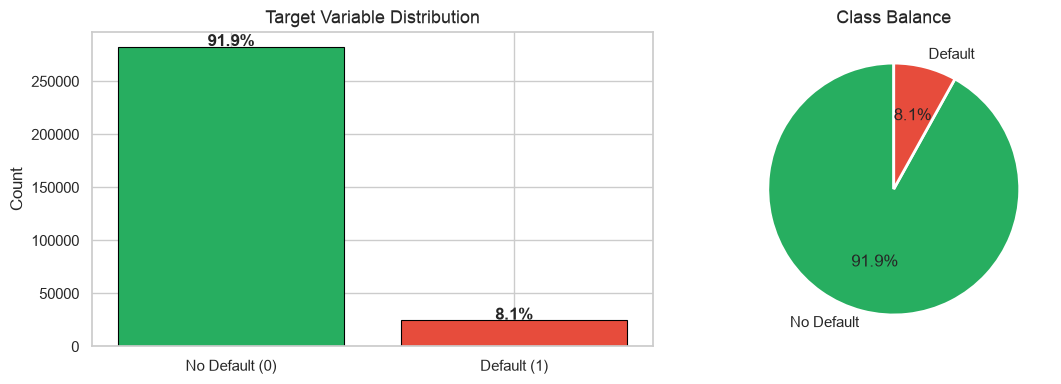


=> Strong class imbalance (~92% vs ~8%).
=> ACCURACY is misleading here: a model that always predicts 0 gets 92% accuracy.
=> We use AUC-ROC as the evaluation metric.


In [5]:
counts = train['TARGET'].value_counts()
pcts   = train['TARGET'].value_counts(normalize=True) * 100

print('TARGET distribution:')
print(f'  0 (no default) : {counts[0]:,}  ({pcts[0]:.2f}%)')
print(f'  1 (default)    : {counts[1]:,}  ({pcts[1]:.2f}%)')
print(f'  Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
                   color=['#27ae60', '#e74c3c'], edgecolor='black', linewidth=0.8)
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{pct:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontsize=13)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['No Default', 'Default'],
            colors=['#27ae60', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontsize=13)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=> Strong class imbalance (~92% vs ~8%).')
print('=> ACCURACY is misleading here: a model that always predicts 0 gets 92% accuracy.')
print('=> We use AUC-ROC as the evaluation metric.')

<a id='4'></a>
## 4. Missing Values Analysis

In [6]:
missing      = train.isnull().sum()
missing_pct  = (missing / len(train) * 100).round(2)
missing_df   = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df   = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

print(f'Columns with missing values   : {len(missing_df)} / {train.shape[1]}')
print(f'Columns with >50% missing     : {(missing_df["pct"] > 50).sum()}')
print(f'Columns with >80% missing     : {(missing_df["pct"] > 80).sum()}')
print('\nTop 25 columns with most missing values:')
missing_df.head(25)

Columns with missing values   : 67 / 122
Columns with >50% missing     : 41
Columns with >80% missing     : 0

Top 25 columns with most missing values:


,count,pct
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_AVG,214865,69.8700
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


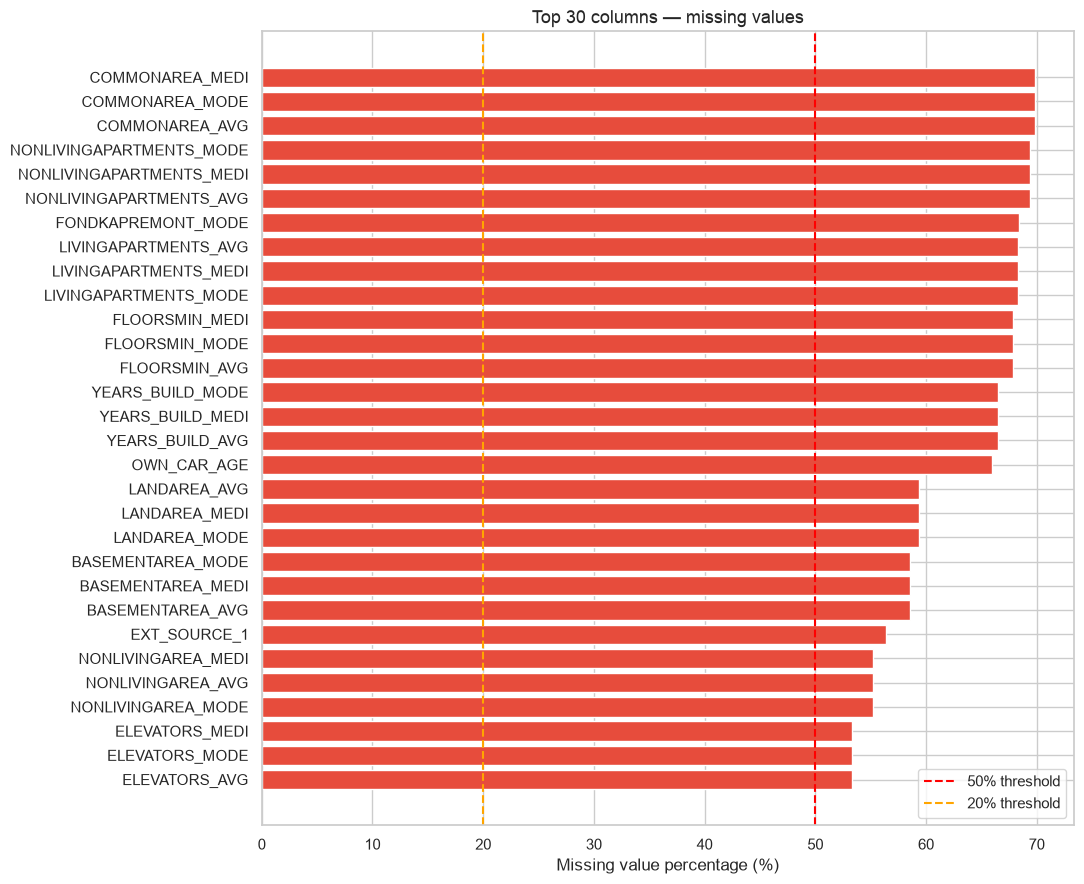


Strategy:
  >50% missing  -> consider dropping or imputing with special "UNKNOWN" category
  Numerical     -> impute with median
  Categorical   -> impute with mode or "MISSING"


In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
top30 = missing_df.head(30)
colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#3498db'
          for p in top30['pct']]
ax.barh(top30.index, top30['pct'], color=colors)
ax.axvline(50, color='red',    linestyle='--', linewidth=1.5, label='50% threshold')
ax.axvline(20, color='orange', linestyle='--', linewidth=1.5, label='20% threshold')
ax.set_xlabel('Missing value percentage (%)')
ax.set_title('Top 30 columns — missing values', fontsize=13)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nStrategy:')
print('  >50% missing  -> consider dropping or imputing with special "UNKNOWN" category')
print('  Numerical     -> impute with median')
print('  Categorical   -> impute with mode or "MISSING"')

<a id='5'></a>
## 5. Variable Types

In [8]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['TARGET', 'SK_ID_CURR']]

print(f'Numerical features   : {len(num_cols)}')
print(f'Categorical features : {len(cat_cols)}')
print(f'\nCategorical features:')
for col in cat_cols:
    n_unique = train[col].nunique()
    print(f'  {col:40s} — {n_unique} unique values')

Numerical features   : 104
Categorical features : 16

Categorical features:
  NAME_CONTRACT_TYPE                       — 2 unique values
  CODE_GENDER                              — 3 unique values
  FLAG_OWN_CAR                             — 2 unique values
  FLAG_OWN_REALTY                          — 2 unique values
  NAME_TYPE_SUITE                          — 7 unique values
  NAME_INCOME_TYPE                         — 8 unique values
  NAME_EDUCATION_TYPE                      — 5 unique values


  NAME_FAMILY_STATUS                       — 6 unique values
  NAME_HOUSING_TYPE                        — 6 unique values


  OCCUPATION_TYPE                          — 18 unique values
  WEEKDAY_APPR_PROCESS_START               — 7 unique values
  ORGANIZATION_TYPE                        — 58 unique values
  FONDKAPREMONT_MODE                       — 4 unique values
  HOUSETYPE_MODE                           — 3 unique values
  WALLSMATERIAL_MODE                       — 7 unique values
  EMERGENCYSTATE_MODE                      — 2 unique values


<a id='6'></a>
## 6. Numerical Features Analysis

We focus on the most interpretable and likely predictive numerical features.

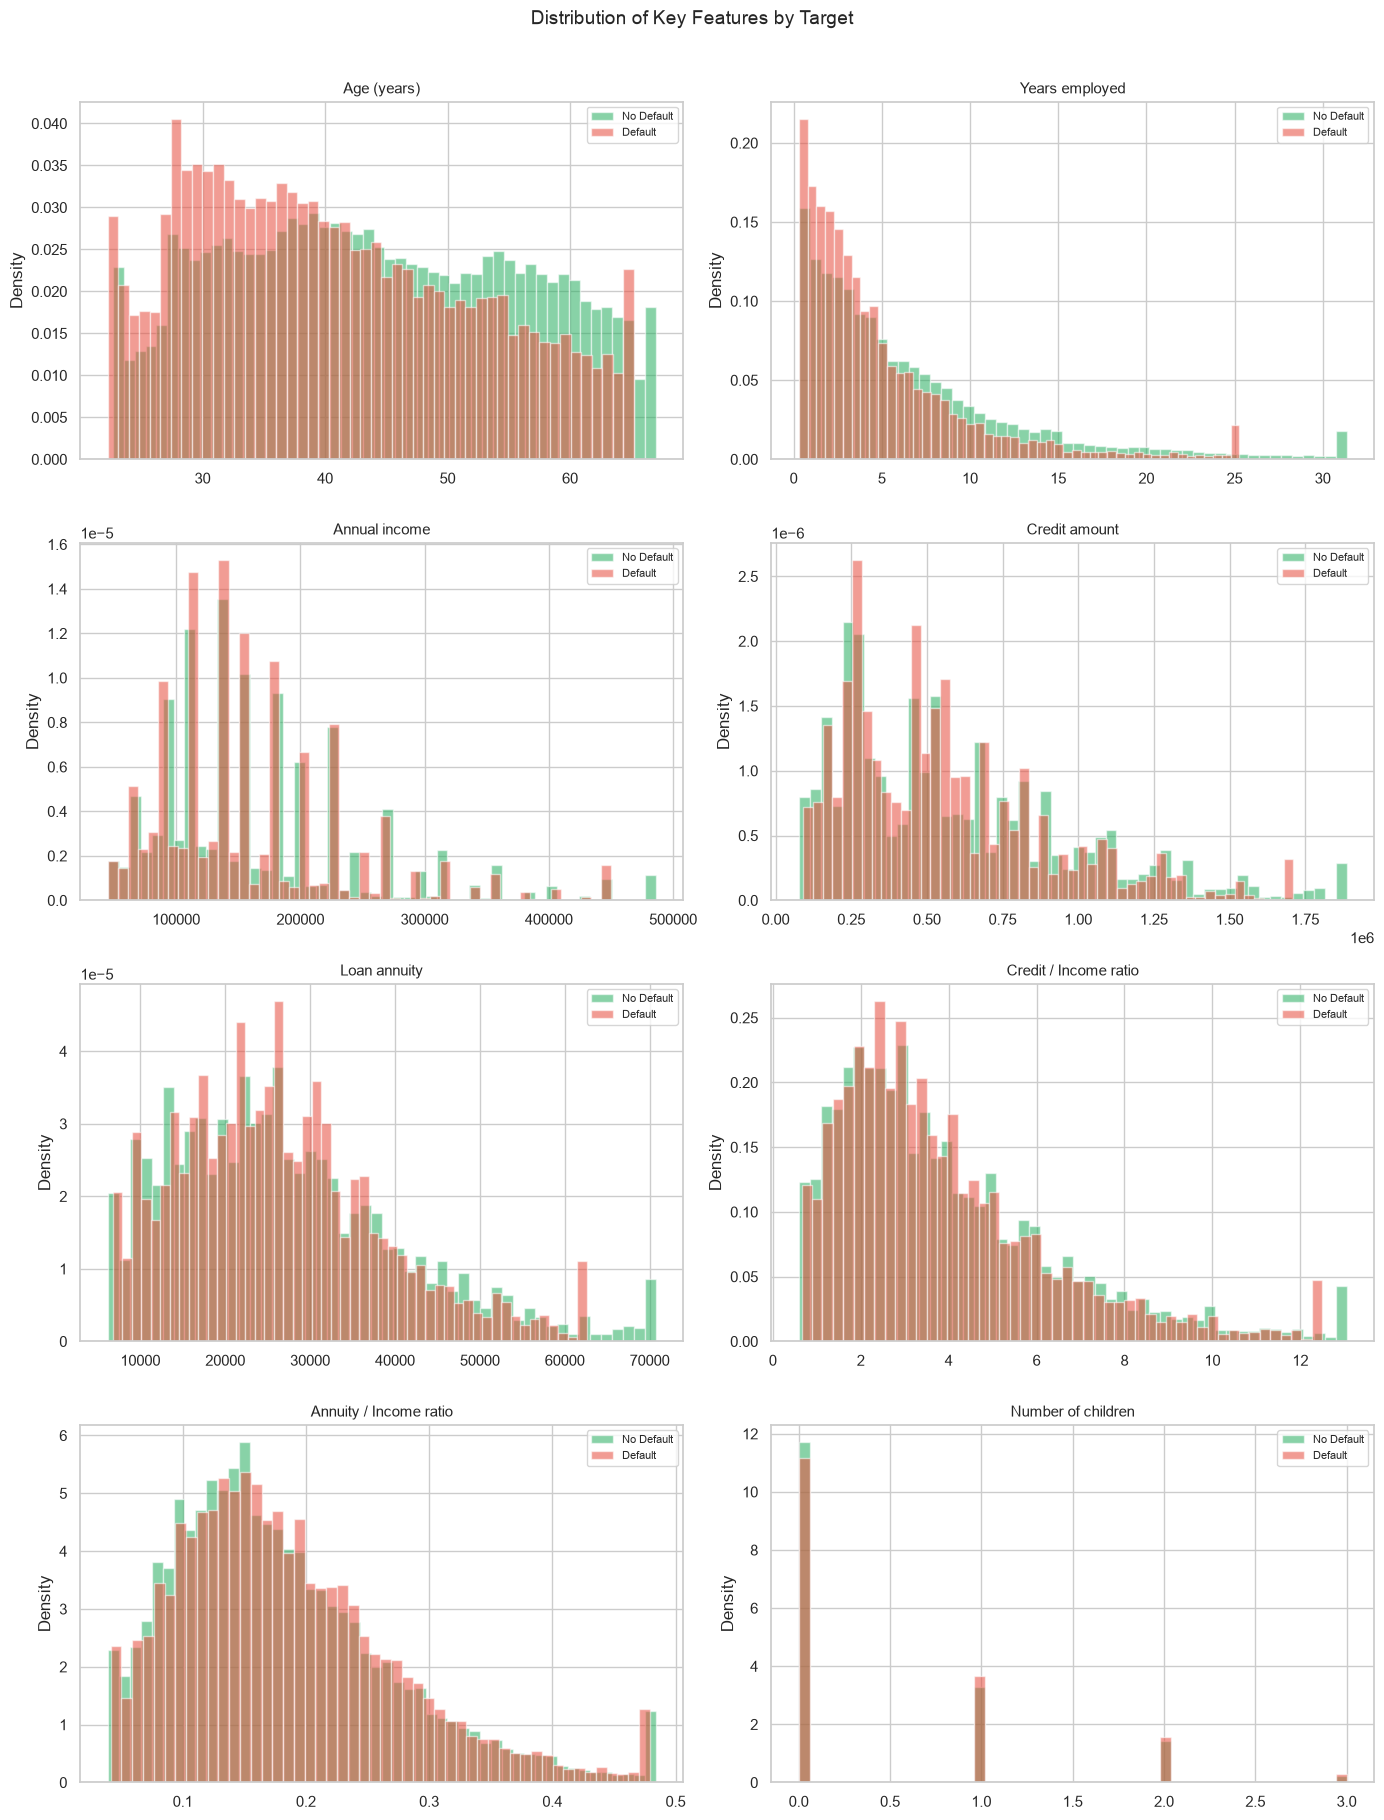

In [9]:
# Create derived features for readability
train['AGE_YEARS']         = (-train['DAYS_BIRTH']) / 365
train['YEARS_EMPLOYED']    = train['DAYS_EMPLOYED'].replace(365243, np.nan) / -365
train['CREDIT_INCOME_RATIO']  = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']

key_features = {
    'AGE_YEARS':            'Age (years)',
    'YEARS_EMPLOYED':       'Years employed',
    'AMT_INCOME_TOTAL':     'Annual income',
    'AMT_CREDIT':           'Credit amount',
    'AMT_ANNUITY':          'Loan annuity',
    'CREDIT_INCOME_RATIO':  'Credit / Income ratio',
    'ANNUITY_INCOME_RATIO': 'Annuity / Income ratio',
    'CNT_CHILDREN':         'Number of children',
}

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, (col, label) in enumerate(key_features.items()):
    ax = axes[i]
    for target_val, color, lbl in [(0, '#27ae60', 'No Default'), (1, '#e74c3c', 'Default')]:
        data = train[train['TARGET'] == target_val][col].dropna()
        # Cap extreme values for readability
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(p1, p99)
        ax.hist(data, bins=50, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle('Distribution of Key Features by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Mean of key features by TARGET
features_to_compare = list(key_features.keys())
comparison = train.groupby('TARGET')[features_to_compare].mean().T
comparison.columns = ['No Default (0)', 'Default (1)']
comparison['Difference (%)'] = ((comparison['Default (1)'] - comparison['No Default (0)'])
                                 / comparison['No Default (0)'].abs() * 100).round(1)
comparison

,No Default (0),Default (1),Difference (%)
AGE_YEARS,44.2142,40.7804,-7.8000
YEARS_EMPLOYED,6.6798,4.9724,-25.6000
AMT_INCOME_TOTAL,169077.7223,165611.7609,-2.0000
AMT_CREDIT,602648.2820,557778.5277,-7.4000
AMT_ANNUITY,27163.6233,26481.7443,-2.5000
CREDIT_INCOME_RATIO,3.9637,3.8874,-1.9000
ANNUITY_INCOME_RATIO,0.1805,0.1855,2.7000
CNT_CHILDREN,0.4129,0.4638,12.3000


<a id='7'></a>
## 7. Categorical Features Analysis

We compute the **default rate** for each category to identify high-risk groups.

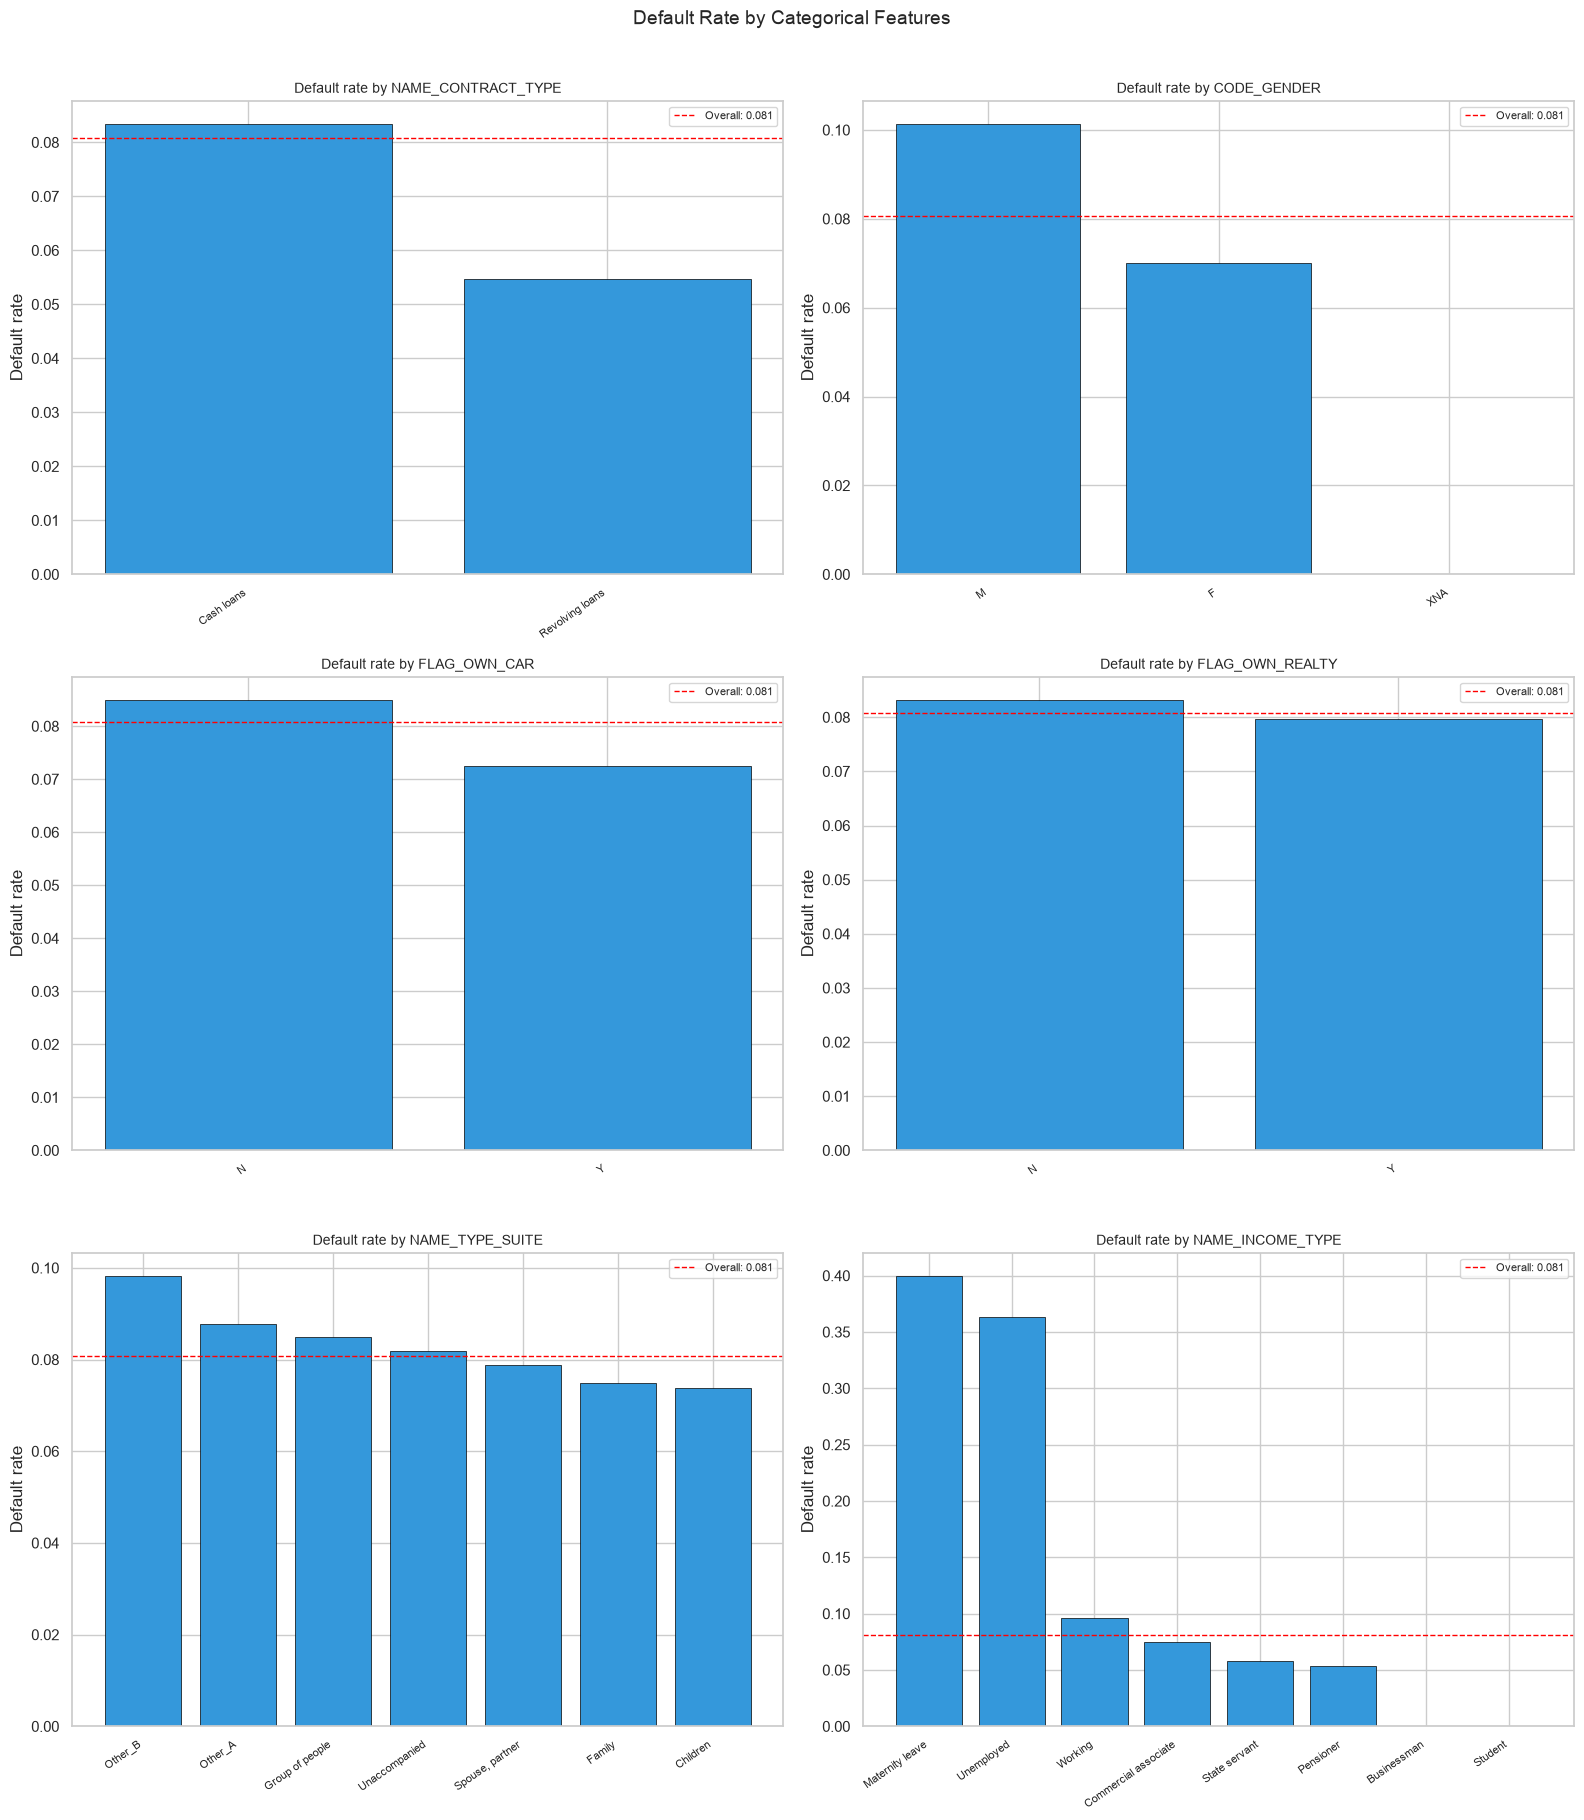

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    ax = axes[i]
    default_rate = (train.groupby(col)['TARGET']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'default_rate', 'count': 'n'})
                    .sort_values('default_rate', ascending=False))
    
    bars = ax.bar(range(len(default_rate)), default_rate['default_rate'],
                  color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(default_rate)))
    ax.set_xticklabels(default_rate.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'Default rate by {col}', fontsize=10)
    ax.set_ylabel('Default rate')
    ax.axhline(train['TARGET'].mean(), color='red', linestyle='--',
               linewidth=1, label=f'Overall: {train["TARGET"].mean():.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Print default rates for all categorical variables
overall_rate = train['TARGET'].mean()
print(f'Overall default rate: {overall_rate:.4f} ({overall_rate*100:.2f}%)\n')

for col in cat_cols:
    rates = (train.groupby(col)['TARGET'].mean()
             .sort_values(ascending=False)
             .to_frame('default_rate'))
    rates['vs_average'] = rates['default_rate'] - overall_rate
    print(f'--- {col} ---')
    print(rates.to_string())
    print()

Overall default rate: 0.0807 (8.07%)

--- NAME_CONTRACT_TYPE ---
                    default_rate  vs_average
NAME_CONTRACT_TYPE                          
Cash loans                0.0835      0.0027
Revolving loans           0.0548     -0.0259

--- CODE_GENDER ---
             default_rate  vs_average
CODE_GENDER                          
M                  0.1014      0.0207
F                  0.0700     -0.0107
XNA                0.0000     -0.0807

--- FLAG_OWN_CAR ---
              default_rate  vs_average
FLAG_OWN_CAR                          
N                   0.0850      0.0043
Y                   0.0724     -0.0083

--- FLAG_OWN_REALTY ---
                 default_rate  vs_average
FLAG_OWN_REALTY                          
N                      0.0832      0.0025
Y                      0.0796     -0.0011



--- NAME_TYPE_SUITE ---
                 default_rate  vs_average
NAME_TYPE_SUITE                          
Other_B                0.0983      0.0176
Other_A                0.0878      0.0070
Group of people        0.0849      0.0041
Unaccompanied          0.0818      0.0011
Spouse, partner        0.0787     -0.0020
Family                 0.0749     -0.0058
Children               0.0738     -0.0070

--- NAME_INCOME_TYPE ---
                      default_rate  vs_average
NAME_INCOME_TYPE                              
Maternity leave             0.4000      0.3193
Unemployed                  0.3636      0.2829
Working                     0.0959      0.0152
Commercial associate        0.0748     -0.0059
State servant               0.0575     -0.0232
Pensioner                   0.0539     -0.0269
Businessman                 0.0000     -0.0807
Student                     0.0000     -0.0807

--- NAME_EDUCATION_TYPE ---
                               default_rate  vs_average
NAME_EDUCATION_TY

--- OCCUPATION_TYPE ---
                       default_rate  vs_average
OCCUPATION_TYPE                                
Low-skill Laborers           0.1715      0.0908
Drivers                      0.1133      0.0325
Waiters/barmen staff         0.1128      0.0320
Security staff               0.1074      0.0267
Laborers                     0.1058      0.0251
Cooking staff                0.1044      0.0237
Sales staff                  0.0963      0.0156
Cleaning staff               0.0961      0.0153
Realty agents                0.0786     -0.0022
Secretaries                  0.0705     -0.0102
Medicine staff               0.0670     -0.0137
Private service staff        0.0660     -0.0147
IT staff                     0.0646     -0.0161
HR staff                     0.0639     -0.0168
Core staff                   0.0630     -0.0177
Managers                     0.0621     -0.0186
High skill tech staff        0.0616     -0.0191
Accountants                  0.0483     -0.0324

--- WEEKDAY_APP

--- EMERGENCYSTATE_MODE ---
                     default_rate  vs_average
EMERGENCYSTATE_MODE                          
Yes                        0.0958      0.0151
No                         0.0696     -0.0111



<a id='8'></a>
## 8. External Score Features (EXT_SOURCE)

`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` are normalized scores from external data sources.
They are among the **strongest predictors** of default in this dataset.

Correlation with TARGET:
  EXT_SOURCE_1: r = -0.1553  |  56.4% missing
  EXT_SOURCE_2: r = -0.1605  |  0.2% missing
  EXT_SOURCE_3: r = -0.1789  |  19.8% missing


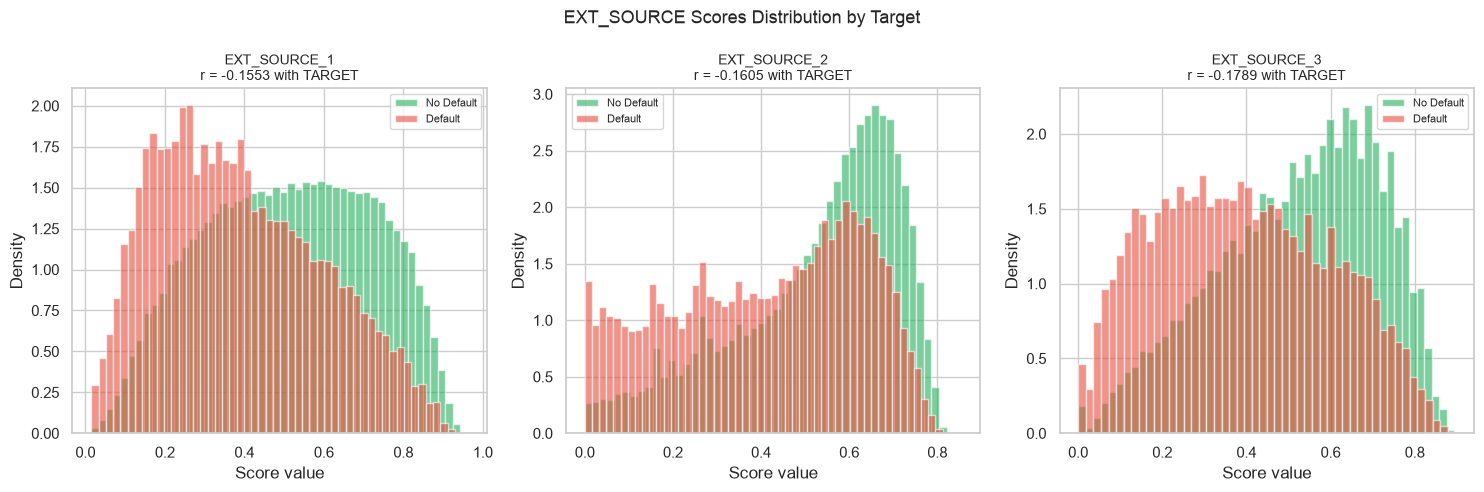

In [13]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('Correlation with TARGET:')
for col in ext_cols:
    corr = train[col].corr(train['TARGET'])
    missing_pct_col = train[col].isnull().mean() * 100
    print(f'  {col}: r = {corr:.4f}  |  {missing_pct_col:.1f}% missing')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ext_cols):
    for target_val, color, lbl in [(0, '#27ae60', 'No Default'), (1, '#e74c3c', 'Default')]:
        data = train[train['TARGET'] == target_val][col].dropna()
        ax.hist(data, bins=50, alpha=0.6, color=color, label=lbl, density=True)
    corr = train[col].corr(train['TARGET'])
    ax.set_title(f'{col}\nr = {corr:.4f} with TARGET', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Score value')
    ax.set_ylabel('Density')

plt.suptitle('EXT_SOURCE Scores Distribution by Target', fontsize=13)
plt.tight_layout()
plt.savefig('ext_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Combined EXT_SOURCE feature
train['EXT_SOURCE_MEAN']   = train[ext_cols].mean(axis=1)
train['EXT_SOURCE_MIN']    = train[ext_cols].min(axis=1)
train['EXT_SOURCE_PROD']   = train[ext_cols].prod(axis=1)

print('Correlation of combined EXT_SOURCE features with TARGET:')
for feat in ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PROD']:
    r = train[feat].corr(train['TARGET'])
    print(f'  {feat}: r = {r:.4f}')

Correlation of combined EXT_SOURCE features with TARGET:
  EXT_SOURCE_MEAN: r = -0.2221
  EXT_SOURCE_MIN: r = -0.1853
  EXT_SOURCE_PROD: r = -0.1389


<a id='9'></a>
## 9. Correlation with TARGET — Top Predictive Features

In [15]:
# Select only numeric columns (excluding IDs)
numeric_df    = train.select_dtypes(include=[np.number]).drop(columns=['SK_ID_CURR'])
correlations  = numeric_df.corr()['TARGET'].drop('TARGET')
corr_abs      = correlations.abs().sort_values(ascending=False)

print('Top 25 features by absolute correlation with TARGET:')
top25 = corr_abs.head(25)
df_corr = pd.DataFrame({
    'correlation': correlations[top25.index],
    'abs_correlation': top25
})
print(df_corr.to_string())

Top 25 features by absolute correlation with TARGET:
                             correlation  abs_correlation
EXT_SOURCE_MEAN                  -0.2221           0.2221
EXT_SOURCE_MIN                   -0.1853           0.1853
EXT_SOURCE_3                     -0.1789           0.1789
EXT_SOURCE_2                     -0.1605           0.1605
EXT_SOURCE_1                     -0.1553           0.1553
EXT_SOURCE_PROD                  -0.1389           0.1389
AGE_YEARS                        -0.0782           0.0782
DAYS_BIRTH                        0.0782           0.0782
YEARS_EMPLOYED                   -0.0750           0.0750
REGION_RATING_CLIENT_W_CITY       0.0609           0.0609
REGION_RATING_CLIENT              0.0589           0.0589
DAYS_LAST_PHONE_CHANGE            0.0552           0.0552
DAYS_ID_PUBLISH                   0.0515           0.0515
REG_CITY_NOT_WORK_CITY            0.0510           0.0510
FLAG_EMP_PHONE                    0.0460           0.0460
DAYS_EMPLOYED      

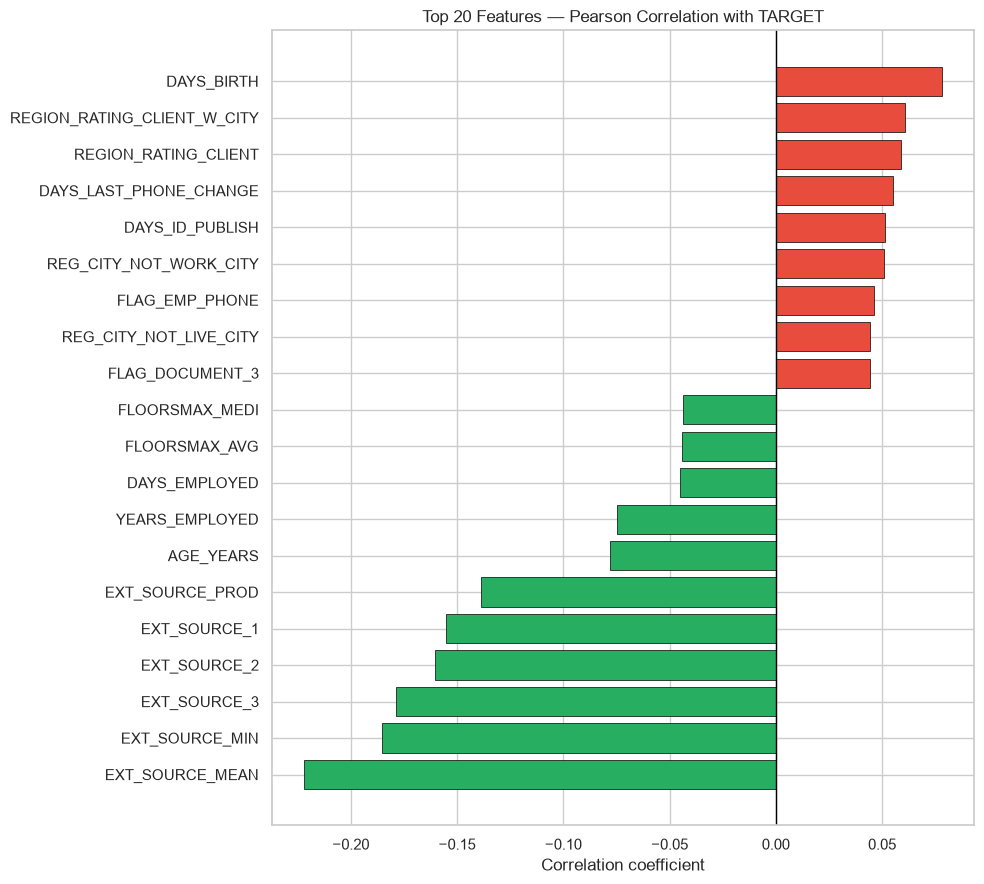


Positive correlation (red)  -> feature increases default probability
Negative correlation (green)-> feature decreases default probability


In [16]:
fig, ax = plt.subplots(figsize=(10, 9))
top20 = correlations[corr_abs.head(20).index].sort_values()
colors = ['#e74c3c' if v > 0 else '#27ae60' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 20 Features — Pearson Correlation with TARGET', fontsize=12)
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('correlations_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPositive correlation (red)  -> feature increases default probability')
print('Negative correlation (green)-> feature decreases default probability')

<a id='10'></a>
## 10. Anomaly Detection

Some features contain anomalous values that must be handled before training.

In [17]:
# DAYS_EMPLOYED anomaly: value 365243 represents retired/unemployed clients
print('DAYS_EMPLOYED statistics:')
print(train['DAYS_EMPLOYED'].describe())

n_anom = (train['DAYS_EMPLOYED'] == 365243).sum()
print(f'\nAnomalous value 365243: {n_anom:,} rows ({n_anom/len(train)*100:.1f}%)')

rate_anom   = train[train['DAYS_EMPLOYED'] == 365243]['TARGET'].mean()
rate_normal = train[train['DAYS_EMPLOYED'] != 365243]['TARGET'].mean()
print(f'Default rate — anomalous rows : {rate_anom:.4f}')
print(f'Default rate — normal rows    : {rate_normal:.4f}')
print('=> The anomalous rows carry information — create a binary flag.')

DAYS_EMPLOYED statistics:
count   307511.0000
mean     63815.0459
std     141275.7665
min     -17912.0000
25%      -2760.0000
50%      -1213.0000
75%       -289.0000
max     365243.0000
Name: DAYS_EMPLOYED, dtype: float64

Anomalous value 365243: 55,374 rows (18.0%)


Default rate — anomalous rows : 0.0540
Default rate — normal rows    : 0.0866
=> The anomalous rows carry information — create a binary flag.


In [18]:
# Check other potential anomalies
print('AMT_INCOME_TOTAL — top 10 values:')
print(train['AMT_INCOME_TOTAL'].nlargest(10).values)

print('\nDAYS_BIRTH range (in years):')
print(f'  Min age: {-train["DAYS_BIRTH"].max()/365:.1f} years')
print(f'  Max age: {-train["DAYS_BIRTH"].min()/365:.1f} years')

print('\nCNT_CHILDREN distribution:')
print(train['CNT_CHILDREN'].value_counts().head(10))

AMT_INCOME_TOTAL — top 10 values:
[1.1700000e+08 1.8000090e+07 1.3500000e+07 9.0000000e+06 6.7500000e+06
 4.5000000e+06 4.5000000e+06 4.5000000e+06 4.5000000e+06 3.9500595e+06]

DAYS_BIRTH range (in years):
  Min age: 20.5 years
  Max age: 69.1 years

CNT_CHILDREN distribution:
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
Name: count, dtype: int64


<a id='11'></a>
## 11. Overview of Supplementary Tables

These tables provide **historical behavioral data** — very useful for feature engineering but need aggregation before joining to the main table.

In [19]:
import os

supplementary_files = {
    'bureau.csv':                'Previous credits at other financial institutions',
    'bureau_balance.csv':        'Monthly balance of bureau credits',
    'previous_application.csv':  'Previous Home Credit loan applications',
    'POS_CASH_balance.csv':      'Monthly POS/cash loan snapshots',
    'credit_card_balance.csv':   'Monthly credit card balance snapshots',
    'installments_payments.csv': 'Installment payment history',
}

print(f'{"File":<35} {"Description":<45} {"Size (MB)":>10}')
print('-' * 95)
for fname, desc in supplementary_files.items():
    fpath = DATA_PATH + fname
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'{fname:<35} {desc:<45} {size_mb:>10.1f}')

File                                Description                                    Size (MB)
-----------------------------------------------------------------------------------------------
bureau.csv                          Previous credits at other financial institutions      170.0
bureau_balance.csv                  Monthly balance of bureau credits                  375.6
previous_application.csv            Previous Home Credit loan applications             405.0
POS_CASH_balance.csv                Monthly POS/cash loan snapshots                    392.7
credit_card_balance.csv             Monthly credit card balance snapshots              424.6
installments_payments.csv           Installment payment history                        723.1


In [20]:
# Quick peek at bureau.csv
bureau = pd.read_csv(DATA_PATH + 'bureau.csv', nrows=5000)
print(f'bureau.csv columns ({len(bureau.columns)}):')
print(list(bureau.columns))
print(f'\nRows per SK_ID_CURR (mean): {bureau.groupby("SK_ID_CURR").size().mean():.2f}')
print(f'Rows per SK_ID_CURR (max) : {bureau.groupby("SK_ID_CURR").size().max()}')

bureau.csv columns (17):
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Rows per SK_ID_CURR (mean): 4.98
Rows per SK_ID_CURR (max) : 27


In [21]:
# Quick peek at previous_application.csv
prev = pd.read_csv(DATA_PATH + 'previous_application.csv', nrows=5000)
print(f'previous_application.csv columns ({len(prev.columns)}):')
print(list(prev.columns))
print(f'\nContract status distribution:')
if 'NAME_CONTRACT_STATUS' in prev.columns:
    print(prev['NAME_CONTRACT_STATUS'].value_counts().to_string())

del prev, bureau  # Free memory

previous_application.csv columns (37):
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

Contract status distribution:
NAME_CONTRACT_STATUS
Approved        3266
Refused          873
Canceled         761
Unused offer     100


<a id='12'></a>
## 12. Conclusions & Feature Engineering Plan

### Key Findings

| Finding | Impact |
|---|---|
| Strong class imbalance (~92% vs ~8%) | Use AUC-ROC, not accuracy; use `class_weight='balanced'` |
| `EXT_SOURCE_1/2/3` are top predictors | Always include; handle ~56% missing in EXT_SOURCE_1 |
| `DAYS_EMPLOYED = 365243` anomaly | Create `DAYS_EMPLOYED_ANOM` binary flag |
| Multiple supplementary tables | Aggregation features = key to AUC > 62% |

In [22]:
print("""
=============================================================
   FEATURE ENGINEERING PLAN
=============================================================

--- From application_train/test.csv ---

  New features:
  - AGE_YEARS                  = -DAYS_BIRTH / 365
  - DAYS_EMPLOYED_ANOM         = 1 if DAYS_EMPLOYED == 365243 else 0
  - DAYS_EMPLOYED (clean)      = replace 365243 with NaN
  - CREDIT_INCOME_RATIO        = AMT_CREDIT / AMT_INCOME_TOTAL
  - ANNUITY_INCOME_RATIO       = AMT_ANNUITY / AMT_INCOME_TOTAL
  - CREDIT_GOODS_RATIO         = AMT_CREDIT / AMT_GOODS_PRICE
  - EXT_SOURCE_MEAN            = mean(EXT_SOURCE_1, 2, 3)
  - EXT_SOURCE_MIN             = min(EXT_SOURCE_1, 2, 3)
  - INCOME_PER_PERSON          = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS

--- From bureau.csv (aggregate per SK_ID_CURR) ---

  - BUREAU_COUNT               = number of past credits
  - BUREAU_ACTIVE_COUNT        = number of active credits
  - BUREAU_DAYS_CREDIT_MEAN    = avg days since past credit applied
  - BUREAU_CREDIT_SUM_DEBT     = total debt in bureau credits
  - BUREAU_OVERDUE_SUM         = total overdue amounts

--- From previous_application.csv (aggregate per SK_ID_CURR) ---

  - PREV_COUNT                 = number of previous applications
  - PREV_APPROVED_COUNT        = number approved
  - PREV_REFUSED_COUNT         = number refused
  - PREV_APPROVE_RATE          = approved / total
  - PREV_AMT_CREDIT_MEAN       = avg credit amount of past loans

--- From installments_payments.csv (aggregate per SK_ID_CURR) ---

  - INSTAL_PAYMENT_DIFF_MEAN   = avg(amt_payment - amt_instalment)
  - INSTAL_DAYS_LATE_MEAN      = avg days past due
  - INSTAL_LATE_COUNT          = number of late payments

--- Model ---

  Baseline : Logistic Regression (interpretable, fast)
  Main     : LightGBM (handles missing values natively, best AUC)
  Tuning   : Optuna or GridSearchCV

=============================================================
""")


   FEATURE ENGINEERING PLAN

--- From application_train/test.csv ---

  New features:
  - AGE_YEARS                  = -DAYS_BIRTH / 365
  - DAYS_EMPLOYED_ANOM         = 1 if DAYS_EMPLOYED == 365243 else 0
  - DAYS_EMPLOYED (clean)      = replace 365243 with NaN
  - CREDIT_INCOME_RATIO        = AMT_CREDIT / AMT_INCOME_TOTAL
  - ANNUITY_INCOME_RATIO       = AMT_ANNUITY / AMT_INCOME_TOTAL
  - CREDIT_GOODS_RATIO         = AMT_CREDIT / AMT_GOODS_PRICE
  - EXT_SOURCE_MEAN            = mean(EXT_SOURCE_1, 2, 3)
  - EXT_SOURCE_MIN             = min(EXT_SOURCE_1, 2, 3)
  - INCOME_PER_PERSON          = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS

--- From bureau.csv (aggregate per SK_ID_CURR) ---

  - BUREAU_COUNT               = number of past credits
  - BUREAU_ACTIVE_COUNT        = number of active credits
  - BUREAU_DAYS_CREDIT_MEAN    = avg days since past credit applied
  - BUREAU_CREDIT_SUM_DEBT     = total debt in bureau credits
  - BUREAU_OVERDUE_SUM         = total overdue amounts

--- From pr